# Time series prediction using LSTM

## Dataset
- Daily minimum temperatures in Melbourne, Australia, 1981-1990
- Units: Degrees Celcius

## Question 1

### Load the data
- load daily-minimum-temperatures-in-me.csv

In [1]:
# if you are using google colab
#from google.colab import files
#files.upload()

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity='all'

In [3]:
import  pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import math
from sklearn.metrics import mean_squared_error
import tensorflow as tf
tf.set_random_seed(42)
tf.__version__
tf.keras.__version__
tf.reset_default_graph()


C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:519: FutureWarning: Passi

'1.14.0'

'2.2.4-tf'

In [4]:
df = pd.read_csv('./daily-minimum-temperatures-in-me.csv')


### Print the data
- First 5 rows only

In [5]:
print(df.head())

         Date  Temperature
0  1981-01-01         20.7
1  1981-01-02         17.9
2  1981-01-03         18.8
3  1981-01-04         14.6
4  1981-01-05         15.8


### Set index column
- Set the DataFrame index using "Date" column

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Temperature
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


## Question 2

### Check the total count of null values in the data

In [7]:
 def get_all_num_cols(df, verbose=False):
    """
    This routine returns the list of all numeric columns, in a pandas dataframe.This list is a possible mix of both
    null & non-null columns
    :param verbose:
    :param df:
    :return: list
    """
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if verbose:
        print("*********************************************************************************")
        print("The list of all NUMERIC-COLUMNS is {}".format(num_cols))
        print("*********************************************************************************")
    return num_cols

In [8]:
def get_null_num_cols(df, verbose=False):
    """
    This routine returns the list of all null-numeric columns, in a pandas dataframe.This list only has the null
    numeric columns.
    :param verbose:
    :param df:
    :return: list
    """
    null_num_cols = [x for x in get_all_num_cols(df) if df[x].isnull().any()]
    if verbose:
        print("*********************************************************************************")
        print("The list of all **NULL** NUMERIC-COLUMNS is {}".format(null_num_cols))
        print("*********************************************************************************")
    return null_num_cols

In [9]:
def display_rows_null_num_cols(df):
    """
    This routine prints out the rows, w.r.t. the null-numeric column (one at a time)
    :param df:
    :return: list
    """
    for col in get_null_num_cols(df):
        print("*********************************************************************************")
        print("Following dataframe rows has NULL values, for the NUMERIC column: {}".format(col))
        print("*********************************************************************************")
        print(df[pd.to_numeric(df[col]).isnull()])


In [10]:
display_rows_null_num_cols(df)

### Drop all the rows with null values
- use dropna() method

*** there wasn't any null value

## Question 3

### Describe your dataframe
- use describe() method

In [11]:
df.describe(include='all')

,Temperature
count,3650.000000
mean,11.177753
std,4.071837
min,0.000000
25%,8.300000
50%,11.000000
75%,14.000000
max,26.300000


### Plot the dataframe
- use plot() method

In [12]:
df.plot()


### Get representation of the distribution of data using histogram
- use hist() method

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001E893786C88>]],
      dtype=object)

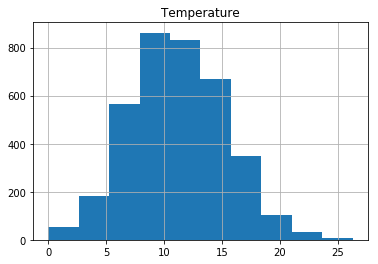

In [13]:
df.hist(bins=10)

### Check minimum and maximum temperature
- use min() and max() methods

In [14]:
# Scaled Data
print('Min', np.min(df))
print('Max', np.max(df))

Min Temperature    0.0
dtype: float64
Max Temperature    26.3
dtype: float64


## Question 4

### Split the dataset into training and testing
- training data: 75%
- testing data: 25%

In [15]:
train = df[:int(len(df) * 0.75)]
test = df[int(len(df) * 0.75):]
print('train: {}\ntest: {}'.format(len(train), len(test)))

train: 2737
test: 913


### Normalize the data
- normalize temperature values using MinMaxScaler
- feature_range: 0-1
- fit MinMaxScaler on train data and transform it
  - use fit_transform() method
- transform test data using MinMaxScaler object
  - use transform() method

In [16]:
dataset = df.astype('float32')

In [17]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(dataset)

In [18]:
print('Min', np.min(scaled))
print('Max', np.max(scaled))

Min 0.0
Max 1.0


In [19]:
print(scaled[:10])

[[0.7870723 ]
 [0.68060837]
 [0.71482889]
 [0.55513311]
 [0.60076048]
 [0.60076048]
 [0.60076048]
 [0.66159696]
 [0.82889733]
 [0.7604563 ]]


### Print scaled train and test data
- print only first 5 values

In [20]:
train = scaled[:int(len(scaled) * 0.75)]
test = scaled[int(len(scaled) * 0.75):]
print('train: {}\ntest: {}'.format(len(train), len(test)))

train: 2737
test: 913


In [21]:
print(train[:5])

[[0.7870723 ]
 [0.68060837]
 [0.71482889]
 [0.55513311]
 [0.60076048]]


In [22]:
print(test[:5])

[[0.22813689]
 [0.22053233]
 [0.1863118 ]
 [0.19011407]
 [0.31939163]]


## Question 5

### Create sequential data
Map the temperature at a particular day 'd' to the temperature at day t
'd+n', where n is any number you define.

For example: to map temperatures of consecutive days, use d+1, i.e. lookback = 1
- Below function takes data as input and returns sequential data.
- X as features and y as labels

In [23]:
import numpy as np
def create_seq_data(data, lookback=1):
  X, y = list(), list()
  
  for day in range((len(data)-lookback)):
    X.append(data[day: day+lookback, 0])
    y.append(data[day+lookback, 0])
  return np.array(X), np.array(y)

### Use the above function to create train and test sets
- Get X_train and y_train
- Get X_test and y_test
- lookback = 1

In [24]:
look_back = 1
X_train, y_train = create_seq_data(train, look_back)
X_test, y_test = create_seq_data(test, look_back)

### Reshape the data
- Reshape X_train and X_test
- use np.reshape() method
- this is to be done to make the data ready for input in model

In [25]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

### Print shape of data
- print shape of X_train and X_test

In [26]:
print(X_train.shape)
print(X_test.shape)

(2736, 1, 1)
(912, 1, 1)


## Question 6

### Define sequential model
- initialize a Sequential model
- add an LSTM layer
  - units: 10
  - stateful: True
  - pass a `batch_input_shape` argument to your layer
  - batch_input_shape: (batch_size, look_back, 1)
    - batch_size: 1
    - look_back: 1
- add Dense layer with 1 neuron

In [27]:
#The network has a visible layer with 1 input, a hidden layer with 4 LSTM blocks or neurons, and an output layer that makes a single value prediction. The default sigmoid activation function is used for the LSTM blocks. The network is trained for 100 epochs and a batch size of 1 is used.
#create and fit the LSTM network
batch_size = 1
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.LSTM(10, batch_input_shape=(batch_size, look_back, 1), stateful=True))
model.add(tf.keras.layers.Dense(1))

W1013 15:30:04.083137 13824 deprecation.py:506] From C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\ops\init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


## Question 7

### compile your model
- loss: mean_squared_error
- optimizer: adam

In [28]:
model.compile(loss='mean_squared_error', optimizer='adam')

### summarize your model
- use summary() method

In [29]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm (LSTM)                  (1, 10)                   480       
_________________________________________________________________
dense (Dense)                (1, 1)                    11        
Total params: 491
Trainable params: 491
Non-trainable params: 0
_________________________________________________________________


## Question 8

### fit your model
- epochs: 50
- batch_size: 1

In [30]:
model.fit(X_train, y_train, epochs=50, batch_size=batch_size, verbose=2, shuffle=True)

W1013 15:30:07.240138 13824 deprecation.py:323] From C:\Users\ojhaj\Anaconda3\lib\site-packages\tensorflow\python\ops\math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Epoch 1/50
2736/2736 - 14s - loss: 0.0154
Epoch 2/50
2736/2736 - 11s - loss: 0.0103
Epoch 3/50
2736/2736 - 10s - loss: 0.0101
Epoch 4/50
2736/2736 - 10s - loss: 0.0100
Epoch 5/50
2736/2736 - 10s - loss: 0.0101
Epoch 6/50
2736/2736 - 10s - loss: 0.0101
Epoch 7/50
2736/2736 - 10s - loss: 0.0100
Epoch 8/50
2736/2736 - 10s - loss: 0.0100
Epoch 9/50
2736/2736 - 10s - loss: 0.0100
Epoch 10/50
2736/2736 - 10s - loss: 0.0099
Epoch 11/50
2736/2736 - 11s - loss: 0.0100
Epoch 12/50
2736/2736 - 10s - loss: 0.0100
Epoch 13/50
2736/2736 - 10s - loss: 0.0099
Epoch 14/50
2736/2736 - 11s - loss: 0.0099
Epoch 15/50
2736/2736 - 12s - loss: 0.0100
Epoch 16/50
2736/2736 - 10s - loss: 0.0100
Epoch 17/50
2736/2736 - 10s - loss: 0.0100
Epoch 18/50
2736/2736 - 10s - loss: 0.0099
Epoch 19/50
2736/2736 - 10s - loss: 0.0099
Epoch 20/50
2736/2736 - 10s - loss: 0.0100
Epoch 21/50
2736/2736 - 10s - loss: 0.0099
Epoch 22/50
2736/2736 - 10s - loss: 0.0099
Epoch 23/50
2736/2736 - 10s - loss: 0.0100
Epoch 24/50
2736/273

## Question 9

### make predictions on train data
- use predict() method
  - batch_size: 1
- store predictions in a variable

In [31]:
trainPredict = model.predict(X_train, batch_size=batch_size)

### reset model state
- if you are using stateful=True in your model then you should call reset_states every time, when you want to make consecutive model calls independent.
- use reset_states() method

In [32]:
model.reset_states()

### make predictions on test data
- use predict() method
  - batch_size: 1
- store predictions in a variable

In [33]:
testPredict = model.predict(X_test, batch_size=batch_size)

## Question 10

### Inverse train predictions and true labels
- use your MinMaxSclarer object
- use inverse_transform() method

In [34]:
# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
y_train = scaler.inverse_transform([y_train])

### Inverse test predictions and true labels
- use your MinMaxSclarer object
- use inverse_transform() method

In [35]:
testPredict = scaler.inverse_transform(testPredict)
y_test = scaler.inverse_transform([y_test])

### Evaluate train predictions
- calculate RMSE
- RMSE = sqrt(mean_squared_error(true_labels, predicted_labels))
- use sqrt() and mean_squared_error() method
- print training RMSE

In [36]:
# calculate root mean squared error
trainScore = math.sqrt(mean_squared_error(y_train[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))

Train Score: 2.66 RMSE


### Evaluate test predictions
- calculate RMSE
- RMSE = sqrt(mean_squared_error(true_labels, predicted_labels))
- use sqrt() and mean_squared_error() method
- print testing RMSE

In [37]:
testScore = math.sqrt(mean_squared_error(y_test[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Test Score: 2.56 RMSE
